In [1]:
import pandas as pd

df = pd.read_csv("Dataset.csv")
print("Columns in dataset:", df.columns)


Columns in dataset: Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')


Online Delivery Availability by Price Range:
Has Online delivery        No       Yes
Price range                            
1                    0.842259  0.157741
2                    0.586894  0.413106
3                    0.708097  0.291903
4                    0.909556  0.090444


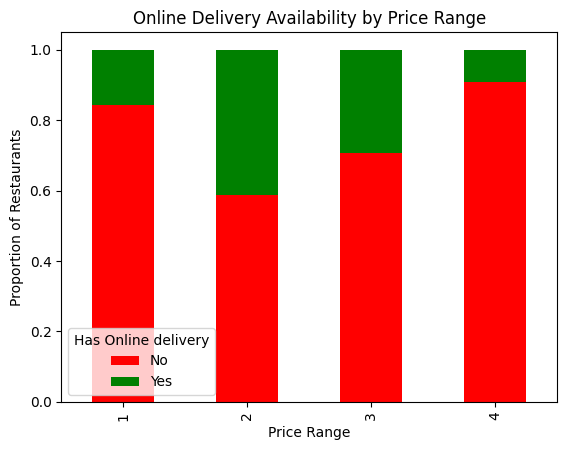

In [2]:
# Group by price range and calculate percentage offering online delivery
online_delivery = df.groupby('Price range')['Has Online delivery'].value_counts(normalize=True).unstack().fillna(0)

print("Online Delivery Availability by Price Range:")
print(online_delivery)

import matplotlib.pyplot as plt
online_delivery.plot(kind='bar', stacked=True, color=['red','green'])
plt.title("Online Delivery Availability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Proportion of Restaurants")
plt.show()



Table Booking Availability by Price Range:
Has Table booking        No       Yes
Price range                          
1                  0.999775  0.000225
2                  0.923225  0.076775
3                  0.542614  0.457386
4                  0.532423  0.467577


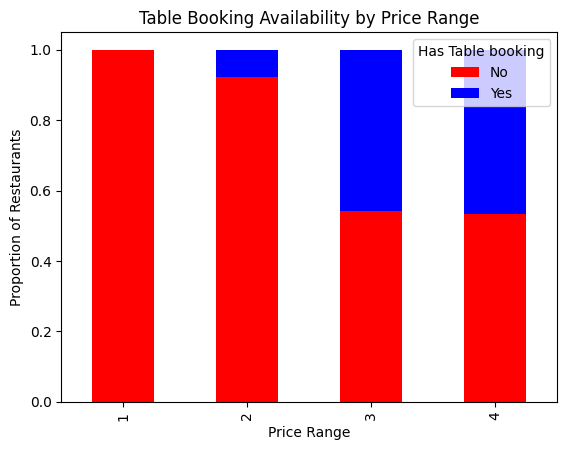

In [3]:
# Group by price range and calculate percentage offering table booking
table_booking = df.groupby('Price range')['Has Table booking'].value_counts(normalize=True).unstack().fillna(0)

print("\nTable Booking Availability by Price Range:")
print(table_booking)

table_booking.plot(kind='bar', stacked=True, color=['red','blue'])
plt.title("Table Booking Availability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Proportion of Restaurants")
plt.show()


In [4]:
# Average rating by price range for restaurants with/without services
avg_rating_online = df.groupby(['Price range','Has Online delivery'])['Aggregate rating'].mean()
avg_rating_table = df.groupby(['Price range','Has Table booking'])['Aggregate rating'].mean()

print("\nAverage Rating by Price Range & Online Delivery:")
print(avg_rating_online)

print("\nAverage Rating by Price Range & Table Booking:")
print(avg_rating_table)



Average Rating by Price Range & Online Delivery:
Price range  Has Online delivery
1            No                     1.809778
             Yes                    3.014979
2            No                     2.739683
             Yes                    3.227138
3            No                     3.706319
             Yes                    3.627737
4            No                     3.806754
             Yes                    3.930189
Name: Aggregate rating, dtype: float64

Average Rating by Price Range & Table Booking:
Price range  Has Table booking
1            No                   1.999505
             Yes                  3.700000
2            No                   2.927662
             Yes                  3.102092
3            No                   3.835079
             Yes                  3.503416
4            No                   4.015385
             Yes                  3.593066
Name: Aggregate rating, dtype: float64
